## Arquitectura LeNet-5 para Digits-MNIST

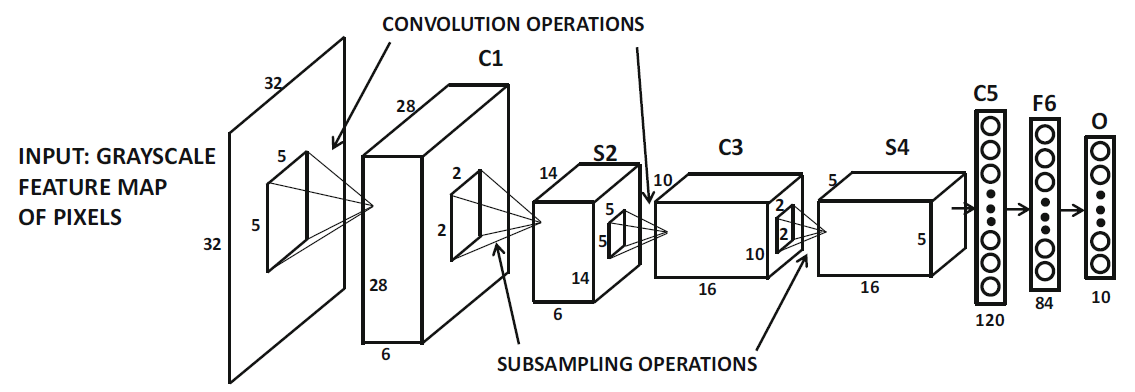

In [1]:
# importa las librerías
import tensorflow as tf
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from numpy import array
from sklearn.metrics import classification_report
import time
from sklearn.metrics import confusion_matrix
import sklearn.model_selection as model_selection

In [19]:
# carga el conjunto de datos de dígitos MNIST
data_cifar = tf.keras.datasets.cifar10
(x_train, y_train), (x_test, y_test) = data_cifar.load_data()

C:\Users\gbgar\Documents\TEC\AD2026\gil-brandon\env\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = RestrictedUnpickler(f, encoding="bytes").load()


In [20]:
# despliega las dimensiones de los arreglos
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)
(50000, 1)
(10000, 1)


In [21]:
# mapea etiqueta a nombre
dicc = {0:"Avión", 1:"Automóvil", 2:"Pájaro", 3:"Gato", 4:"Ciervo",
        5:"Perro", 6:"Rana", 7:"Caballo", 8:"Barco", 9:"Camión"}
dicc

{0: 'Avión',
 1: 'Automóvil',
 2: 'Pájaro',
 3: 'Gato',
 4: 'Ciervo',
 5: 'Perro',
 6: 'Rana',
 7: 'Caballo',
 8: 'Barco',
 9: 'Camión'}

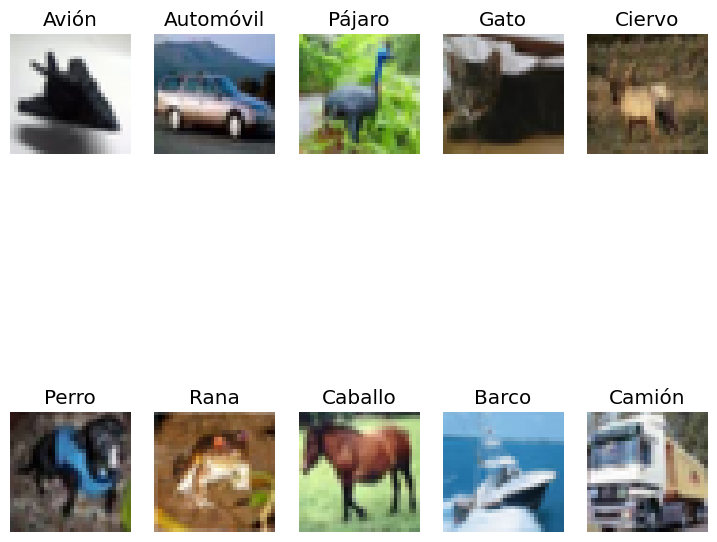

In [23]:
# despliega algunas imágenes del dataset
cc = [29, 4, 6, 9, 3, 27, 0, 7, 8, 1]  
fig=plt.figure(figsize=(9,9))
k=1
for i in cc:
    fig.add_subplot(2, 5, k)
    plt.imshow(x_train[i]) 
    plt.title(dicc[y_train[i][0]]) 
    plt.axis('off')
    k += 1

In [24]:
# normaliza las intensidades de los pixeles de las imágenes
x_train, x_test = x_train/255.0, x_test/255.0

In [25]:
# convierte etiquetas de clase enteras en código binario (one hot)
ytrain = tf.keras.utils.to_categorical(y_train)
ytest = tf.keras.utils.to_categorical(y_test)
print(y_train[0])
print(ytrain[0])

[6]
[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


In [26]:
labels = ["Avión", "Automóvil", "Pájaro", "Gato", "Ciervo", 
          "Perro", "Rana", "Caballo", "Barco", "Camión"]

In [28]:
# crea el modelo LeNet-5 para CIFAR-10
model = tf.keras.models.Sequential([

    # C1: Convolutional layer (Entrada de 32x32x3)
    tf.keras.layers.Conv2D(filters=6, kernel_size=(5,5), strides=(1,1), padding='valid', activation='tanh', input_shape=(32, 32, 3)),

    # S2: Subsampling - Pooling layer:
    tf.keras.layers.MaxPooling2D(pool_size=(2,2), strides=(2,2), padding='valid'),

    # C3: Convolutional layer:
    tf.keras.layers.Conv2D(filters=16, kernel_size=(5,5), strides=(1,1), padding='valid', activation='tanh'),

    # S4: Subsampling - Pooling layer:
    tf.keras.layers.MaxPooling2D(pool_size=(2,2), strides=(2,2), padding='valid'),

    # C5: Flatten & Fully connection:
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(120, activation='tanh'),

    # F6: Fully conection:
    tf.keras.layers.Dense(84, activation='tanh'),

    #Output: Softmax
    tf.keras.layers.Dense(10, activation=tf.nn.softmax)
])

C:\Users\gbgar\Documents\TEC\AD2026\gil-brandon\env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [29]:
# define algunos hiper-parámetros
n_epochs=20
n_batch=64
learning_rate=0.01
opt = tf.keras.optimizers.SGD(learning_rate=learning_rate)

In [30]:
# configura el modelo para entrenamiento
model.compile(optimizer=opt,
   loss='categorical_crossentropy',
   metrics=['accuracy'])

In [31]:
# Entrena el modelo para un número fijo de épocas
Historia = model.fit(x_train, ytrain, validation_data=(x_test, ytest),
                     epochs=n_epochs, batch_size=n_batch)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.2893 - loss: 1.9776 - val_accuracy: 0.3675 - val_loss: 1.7763
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.3915 - loss: 1.7169 - val_accuracy: 0.4087 - val_loss: 1.6599
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.4322 - loss: 1.5969 - val_accuracy: 0.4302 - val_loss: 1.5843
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - accuracy: 0.4582 - loss: 1.5180 - val_accuracy: 0.4529 - val_loss: 1.5252
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.4821 - loss: 1.4563 - val_accuracy: 0.4764 - val_loss: 1.4811
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.5015 - loss: 1.4030 - val_accuracy: 0.4790 - val_loss: 1.4733
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.5170 - loss: 1.3619 - val_accuracy: 0.4709 - val_loss: 1.4449
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.5288 - loss: 1.3251 - 

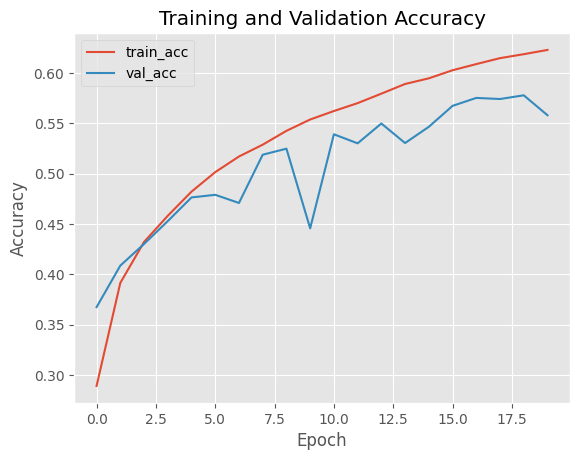

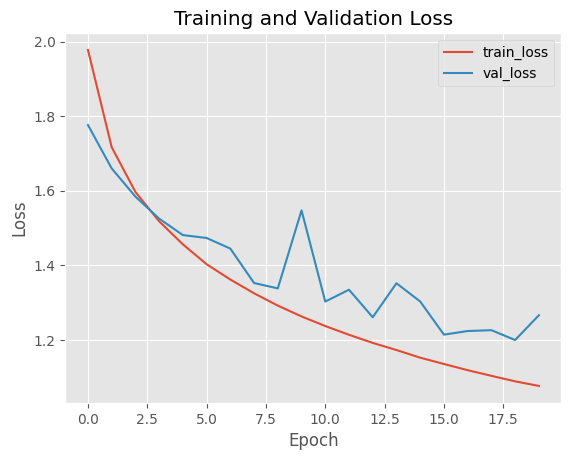

In [32]:
# Despliega las curvas de aprendizaje
H = Historia
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0,n_epochs),H.history["accuracy"],label="train_acc")
plt.plot(np.arange(0,n_epochs),H.history["val_accuracy"],label="val_acc")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.figure()
plt.plot(np.arange(0,n_epochs),H.history["loss"],label="train_loss")
plt.plot(np.arange(0,n_epochs),H.history["val_loss"],label="val_loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [33]:
# estadísticas de desempeño de la red
predictions = model.predict(x_test, batch_size=n_batch)
print(classification_report(ytest.argmax(axis=1),
      predictions.argmax(axis=1),target_names=labels))

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
              precision    recall  f1-score   support

       Avión       0.54      0.69      0.61      1000
   Automóvil       0.53      0.85      0.65      1000
      Pájaro       0.44      0.51      0.47      1000
        Gato       0.41      0.44      0.43      1000
      Ciervo       0.71      0.24      0.36      1000
       Perro       0.54      0.37      0.44      1000
        Rana       0.59      0.70      0.64      1000
     Caballo       0.72      0.57      0.63      1000
       Barco       0.60      0.74      0.66      1000
      Camión       0.75      0.46      0.57      1000

    accuracy                           0.56     10000
   macro avg       0.58      0.56      0.55     10000
weighted avg       0.58      0.56      0.55     10000



In [34]:
# Matriz de confusión
confusion_matrix(ytest.argmax(axis=1), predictions.argmax(axis=1))

array([[692,  74,  39,  15,   3,   4,  12,   3, 144,  14],
       [ 43, 852,   4,   3,   1,   2,  11,   3,  45,  36],
       [122,  34, 511,  78,  22,  64,  91,  28,  41,   9],
       [ 60,  74,  99, 444,  21, 110,  97,  26,  49,  20],
       [ 71,  36, 217, 107, 245,  33, 160,  80,  39,  12],
       [ 29,  32, 122, 259,  16, 374,  64,  56,  41,   7],
       [ 18,  59,  74,  80,   7,  16, 700,  13,  27,   6],
       [ 52,  51,  71,  77,  27,  78,  28, 567,  18,  31],
       [136,  82,   9,   6,   1,   5,   3,   1, 736,  21],
       [ 63, 319,  10,  14,   1,   8,  21,  15,  90, 459]])

In [35]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 6)      │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,008 (242.22 KB)

 Trainable params: 62,006 (242.21 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [37]:
# Cantidad de parámetros de la red
print("Parámetros del Layer conv2d: " + str( 3 * (5*5) * 6 + 6 )) 
print("Parámetros del Layer conv2d_1: " + str( 6 * (5*5) * 16 + 16 ))
print("Parámetros del Layer dense_1_1: " + str( 16 * (5*5) * 120 + 120 )) 
print("Parámetros del Layer dense_1_2: " + str( 120 * (84) + 84 ))
print("Parámetros del Layer dense_1_3: " + str( 84 * (10) + 10 ))

Parámetros del Layer conv2d: 456
Parámetros del Layer conv2d_1: 2416
Parámetros del Layer dense_1_1: 48120
Parámetros del Layer dense_1_2: 10164
Parámetros del Layer dense_1_3: 850


In [38]:
# nuevo modelo Convolucional modernizado para CIFAR-10
model = tf.keras.models.Sequential([

   # Capa Convolucional 1: Más filtros (32) y activación ReLU
   tf.keras.layers.Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu', input_shape=(32, 32, 3)),
   tf.keras.layers.MaxPooling2D(pool_size=(2,2)),

   # Capa Convolucional 2: Aumentamos a 64 filtros
   tf.keras.layers.Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu'),
   tf.keras.layers.MaxPooling2D(pool_size=(2,2)),

   # Flatten & Capa Densa (Fully connected):
   tf.keras.layers.Flatten(),
   tf.keras.layers.Dense(256, activation='relu'),
   
   # Capa de Dropout: Apaga el 50% de las neuronas al azar para evitar que la red memorice los datos
   tf.keras.layers.Dropout(0.5),

   # Capa Densa adicional:
   tf.keras.layers.Dense(128, activation='relu'),

   # Output: Softmax para las 10 clases
   tf.keras.layers.Dense(10, activation='softmax')
])

C:\Users\gbgar\Documents\TEC\AD2026\gil-brandon\env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [41]:
# define algunos hiper-parámetros nuevos
n_epochs = 20
n_batch = 32          
learning_rate = 0.001

opt = tf.keras.optimizers.Adam(learning_rate=learning_rate)

In [42]:
# configura el modelo para entrenamiento
model.compile(optimizer=opt,
   loss='categorical_crossentropy',
   metrics=['accuracy'])

In [43]:
# Entrena el modelo para un número fijo de épocas
Historia = model.fit(x_train, ytrain, validation_data=(x_test, ytest),
                     epochs=n_epochs, batch_size=n_batch)

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 44s 26ms/step - accuracy: 0.4456 - loss: 1.5250 - val_accuracy: 0.5793 - val_loss: 1.1911
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - accuracy: 0.5825 - loss: 1.1731 - val_accuracy: 0.6240 - val_loss: 1.0938
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 40s 26ms/step - accuracy: 0.6431 - loss: 1.0205 - val_accuracy: 0.6612 - val_loss: 0.9595
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - accuracy: 0.6747 - loss: 0.9259 - val_accuracy: 0.6910 - val_loss: 0.8845
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.7011 - loss: 0.8493 - val_accuracy: 0.7061 - val_loss: 0.8491
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 24ms/step - accuracy: 0.7219 - loss: 0.7878 - val_accuracy: 0.7050 - val_loss: 0.8623
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - accuracy: 0.7396 - loss: 0.7337 - val_accuracy: 0.7191 - val_loss: 0.8228
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.7564 -

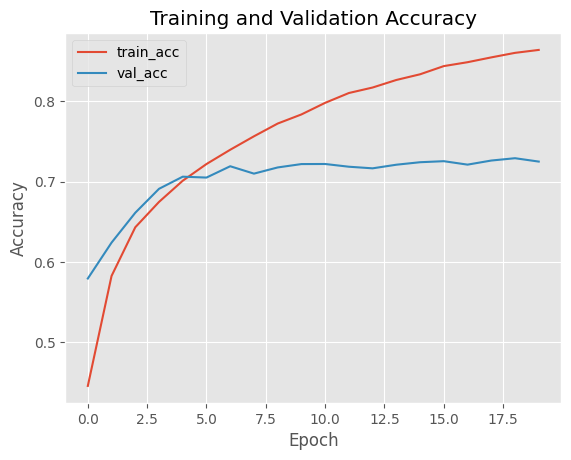

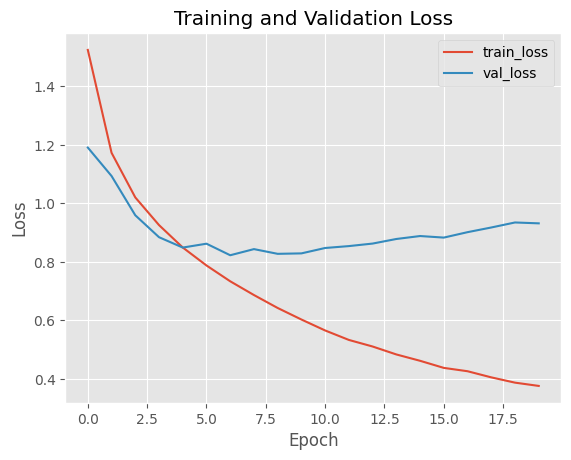

In [44]:
# Despliega las curvas de aprendizaje
H = Historia
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0,n_epochs),H.history["accuracy"],label="train_acc")
plt.plot(np.arange(0,n_epochs),H.history["val_accuracy"],label="val_acc")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.figure()
plt.plot(np.arange(0,n_epochs),H.history["loss"],label="train_loss")
plt.plot(np.arange(0,n_epochs),H.history["val_loss"],label="val_loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [45]:
# estadísticas de desempeño de la red
predictions = model.predict(x_test, batch_size=n_batch)
print(classification_report(ytest.argmax(axis=1),
      predictions.argmax(axis=1),target_names=labels))

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
              precision    recall  f1-score   support

       Avión       0.74      0.79      0.76      1000
   Automóvil       0.87      0.83      0.85      1000
      Pájaro       0.70      0.57      0.63      1000
        Gato       0.48      0.57      0.52      1000
      Ciervo       0.66      0.70      0.68      1000
       Perro       0.61      0.65      0.63      1000
        Rana       0.83      0.72      0.77      1000
     Caballo       0.78      0.78      0.78      1000
       Barco       0.85      0.82      0.84      1000
      Camión       0.81      0.81      0.81      1000

    accuracy                           0.72     10000
   macro avg       0.73      0.72      0.73     10000
weighted avg       0.73      0.72      0.73     10000



In [46]:
# Matriz de confusión
confusion_matrix(ytest.argmax(axis=1), predictions.argmax(axis=1))

array([[792,  13,  30,  30,  23,   8,   7,  14,  48,  35],
       [ 27, 827,   5,  16,   7,   4,   5,   5,  22,  82],
       [ 69,   3, 572,  94,  96,  70,  43,  30,  12,  11],
       [ 24,   8,  39, 573,  69, 187,  35,  39,   9,  17],
       [ 21,   0,  56,  75, 698,  35,  29,  74,   9,   3],
       [  9,   2,  33, 197,  40, 654,  12,  39,   8,   6],
       [  9,   4,  43, 101,  65,  39, 721,   6,   6,   6],
       [ 11,   0,  28,  45,  56,  55,   9, 783,   2,  11],
       [ 72,  31,   6,  24,   6,  11,   6,   2, 819,  23],
       [ 37,  64,   6,  30,   4,   6,   3,  17,  23, 810]])

In [47]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,307,232 (12.62 MB)

 Trainable params: 1,102,410 (4.21 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,204,822 (8.41 MB)

# Reflexión

Inicialmente tomé todo el notebook y lo ejecuté para comprender exactamente el código del tutorial. Traté de obtener una base de datos similar para enfocarme más en la creación del modelo y los hiperparámetros a ajustar que en corregir el código completo. Esto me llevó a CIFAR-10, lo cual me pareció sumamente interesante porque se sentía como el siguiente paso lógico posterior a MNIST. Ya entrando como tal al código, tuve que modificar las dimensiones debido a que el nuevo dataset era RGB en vez de blanco y negro. También, todo el proceso de carga y etiquetado del dataset para que fuera correspondiente. Posteriormente, ajuste los hiperparámetros en ambos modelos para su comparación. Traté de cambiar la mayoría de los hiperparámetros para reportar un cambio drástico. Modifiqué toda la arquitectura original de LeNet-5, cambié las funciones de activación de tanh a relu, subí la cantidad de filtros en las convoluciones a 32 y 64, agregué una capa de Dropout, cambié el optimizador a Adam, reduje el learning rate y bajé el batch size a 32. 

Esto terminó por realizar un cambio marcado, lo cual fue súper revelador para poder entender la construcción de modelos en su totalidad. Ir linea por linea me ayudó muchísimo a ver cómo cada parte del código se conecta con la siguiente. Ver las cosas estructuradas así me hizo comprender que pasar de un modelo a otro es solo cambiar pequeños filtros mientras que el resto del fondo es exactamente lo mismo. Tuve algunas dificultades mientras desarrollaba el código para el nuevo dataset. Principalmente el contar función reshape que me marcaba error y no entendia muy bien porque. Sin embargo, después de investigar descubrí que los canales de CIFAR-10 ya están listos, lo cual me hizo entender mejor el dataset. Otra dificultad grande fue analizar el rendimiento real del modelo a través de las gráficas. En el primer modelo noté que el accuracy se estancaba en un margen muy pobre y la curva de validación daba unos picos violentos. Ese ruido me indicó que al modelo le costaba muchísimo estabilizarse y aprender los patrones generales, probablemente por una tasa de aprendizaje demasiado alta o falta de regularización. El segundo modelo que diseñé con los cambios logró que el accuracy subiera bastante, estabilizándose en un margen superior al primero. Pero al analizar las gráficas con cuidado, noté que existía un problema de overfitting. A partir del epoch 5, se puede ver cómo la pérdida de entrenamiento sigue bajando, pero la de validación empieza a repuntar, creando una brecha sustancial entre ambas. Lo cual es un claro síntoma de overfitting donde se ajusta a los datos de entrenamiento en vez de generalizar para cualquier muestra. 

En conclusión, aprendí que el dataset y las dimensiones de entrada dictan absolutamente todo el comportamiento del modelo. Mientras que MNIST es un dataset muy sencillo, CIFAR-10 te muestra cómo el mero hecho de incluir color puede aumentar la complejidad en varias magnitudes. También el saber que las arquitecturas no necesariamente son fijas y que entrenar redes neuronales es un proceso de prueba y error hasta encontrar hiperparámetros que se ajusten a lo necesario. Sin embargo, creo que lo que más me llevo es la capacidad de interpretación de gráficas. Previo a la actividad, no tenía ni idea de cómo leer o interpretar los valores y gráficas para analizar modelos. Ahora puedo decir con confianza que entiendo dichas gráficas y puedo llegar a conclusiones a partir de ellas. En el futuro planeo implementar técnicas como el Early Stopping para detener el entrenamiento justo en el epoch correcto, y así quedarme con la mejor versión de la red antes de su deficiencia para predicción y generalización.

### Declaración de Uso de IA

Se utilizó IA

• Herramienta: Gemini 3.6 Thinking 

• Uso realizado: Apoyo con documentación de funciones de código y obtención del dataset

• Secciones donde se utilizó: En complemento de código y para propósitos de investigación

• Validación realizada por el estudiante: Revise la documentación de las funciones para entenderlas y revise que los outputs considieran. Me tomé el tiempo de analizar los datasets obtenidos y elegir el que más me llamara la atención.

• Otro (especifique): NA

Confirmo que revisé, verifiqué y asumo la responsabilidad del contenido final entregado.
